In [1]:
# !unzip -o ./Data/cassava-disease.zip -d ./Data/
# !unzip -o ./Data/train.zip -d ./Data/
# !unzip -o ./Data/test.zip -d ./Data/

In [ ]:
%matplotlib inline

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from PIL import Image
import os
from pathlib import Path
from icecream import ic

## Data Preparing

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
train_dataset = datasets.ImageFolder(root="./Data/train", transform=transform_train)
test_dataset = datasets.ImageFolder(root="./Data/test", transform=transform_test)

train_dataset.class_to_idx

{'cbb': 0, 'cbsd': 1, 'cgm': 2, 'cmd': 3, 'healthy': 4}

In [4]:
len(train_dataset)

5656

In [5]:
train_dataset[0][0].shape

torch.Size([3, 256, 256])

In [6]:
labels = [train_dataset[i][1] for i in trange(len(train_dataset))]
train_idx, val_idx = train_test_split(range(len(train_dataset)), stratify=labels, test_size=0.3, random_state=42)

100%|██████████| 5656/5656 [00:30<00:00, 186.36it/s]


In [7]:
train_idx[:10], val_idx[:10]

([2450, 3490, 1885, 1352, 4373, 1281, 4082, 2885, 297, 1471],
 [3823, 4969, 3786, 1652, 862, 4062, 1005, 5469, 462, 1683])

In [8]:
len(train_idx), len(val_idx)

(3959, 1697)

In [9]:
train_data = torch.utils.data.Subset(train_dataset, train_idx)
val_data = torch.utils.data.Subset(train_dataset, val_idx)

In [10]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=8, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False, num_workers=8, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, persistent_workers=True)

In [11]:
def show_images(images, labels):
    f, axes= plt.subplots(1, 10, figsize=(30,5))

    for i, axis in enumerate(axes):
        # переводим картинку из тензора в numpy
        img = images[i].numpy()
        # переводим картинку в размерность (длина, ширина, цветовые каналы)
        img = np.transpose(img, (1, 2, 0))

        axes[i].imshow(img)
        axes[i].set_title(labels[i].numpy())

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1309524].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9920369].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9920369].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3585434

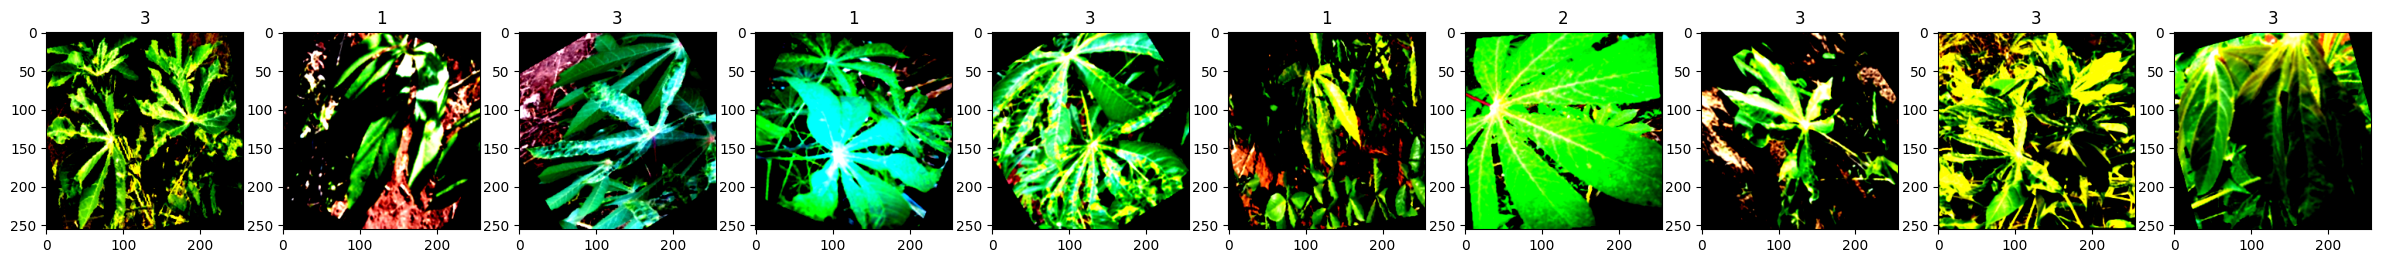

In [12]:
for batch in train_loader:
    # батч картинок и батч ответов к картинкам
    images, labels = batch
    break

show_images(images, labels)

## Model

### MyModel

In [13]:
class CassavaClassifier(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            output_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(CassavaClassifier, self).__init__()

        conv_layers = [
            nn.Conv2d(in_channels=in_ch, out_channels=hidden_ch[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU()
            # nn.Dropout2d(conv_dropout)
        ]

        last_dim = hidden_ch[0]

        for i in range(1, len(hidden_ch)):
            conv_layers.extend([
                nn.Conv2d(in_channels=last_dim, out_channels=hidden_ch[i], kernel_size=3, padding=1),
                nn.BatchNorm2d(hidden_ch[i]),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            last_dim = hidden_ch[i]
        
        self.conv_part = nn.Sequential(*conv_layers)

        fc_layers = []

        last_dim = self._after_conv_shape(img_shape, self.conv_part)
        
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(fc_dropout)
            ])
            last_dim = dim

        fc_layers.extend([
            nn.Linear(last_dim, output_dim)
        ])
        
        self.fc_part = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv_part(x)
        flaten = nn.Flatten()
        x = flaten(x)
        x = self.fc_part(x)
        return x

    def _after_conv_shape(self, img_shape, conv_part) -> np.array:
        X = torch.Tensor(size=[1, *img_shape])
        flat = nn.Flatten()
        X_out = flat(conv_part(X))
        return X_out[0].shape[0]

CassavaClassifier(
    img_shape=(3, 128, 128),
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[128, 64],
    output_dim=5
)

CassavaClassifier(
  (conv_part): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout2d(p=0.2, inplace=False)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.2, inplace=False)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_part): Sequential(
    (0): Linear(in_features=131072, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, tr

#### Train

In [14]:
import os
from tqdm import trange
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def train(
    train_loader: DataLoader,
    val_loader: DataLoader,
    model: nn.Module,
    optimizer: torch.optim.AdamW,
    criterion=nn.CrossEntropyLoss(),
    num_epochs=100,
    model_name="best_model"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    os.makedirs("./models", exist_ok=True)

    train_losses = []
    val_losses = []
    val_metric = []
    best_accuracy = 0.0

    for epoch in trange(num_epochs):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))

        model.eval()
        cur_val_loss = 0.0
        cur_pred_true = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                y_pred = model(X_batch)
                cur_val_loss += criterion(y_pred, y_batch).item()
                cur_pred_true += (y_pred.argmax(1) == y_batch).sum().item()

        val_losses.append(cur_val_loss / len(val_loader))
        cur_accuracy = cur_pred_true / len(val_loader.dataset)
        val_metric.append(cur_accuracy)

        print(f"Epoch {epoch}: Train Loss = {epoch_train_loss/len(train_loader):.4f}, "
              f"Val Loss = {cur_val_loss/len(val_loader):.4f}, "
              f"Val Acc = {cur_accuracy:.4f}")

        if len(val_metric) == 0 or cur_accuracy >= best_accuracy:
            best_accuracy = cur_accuracy
            torch.save(model.state_dict(), f"./models/{model_name}.pth")
            print("Best model saved!")

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label="Train")
            axs[0].plot(val_losses, label="Validation")
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("Validation Accuracy")
            axs[1].plot(val_metric)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    return model

In [ ]:
model = ic(CassavaClassifier(
    img_shape=(3, 256, 256),
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[256, 128, 64],
    output_dim=5
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
criterion = nn.CrossEntropyLoss()

# model = train(
#     train_loader=train_loader,
#     val_loader=val_loader,
#     model=model,
#     optimizer=optimizer,
#     criterion=criterion,
#     num_epochs=100
# )

ic| CassavaClassifier(
        img_shape=(3, 256, 256),
        in_ch=3,
        hidden_ch=[32, 64, 128, 256],
        hidden_fc=[256, 128, 64],
        output_dim=5
    ): CassavaClassifier(
         (conv_part): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (5): ReLU()
           (6): Dropout2d(p=0.2, inplace=False)
           (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (10): ReLU()
           (11): Dropout2d(p=0

In [ ]:
# model = CassavaClassifier(
#     img_shape=(3, 256, 256),
#     in_ch=3,
#     hidden_ch=[32, 64, 128, 256],
#     hidden_fc=[256, 128, 64],
#     output_dim=5
# )

# model.load_state_dict(torch.load('./models/best_model.pth'))
# model.eval()
# model

RuntimeError: Error(s) in loading state_dict for CassavaClassifier:
	Missing key(s) in state_dict: "conv_part.0.weight", "conv_part.0.bias", "conv_part.1.weight", "conv_part.1.bias", "conv_part.1.running_mean", "conv_part.1.running_var", "conv_part.3.weight", "conv_part.3.bias", "conv_part.4.weight", "conv_part.4.bias", "conv_part.4.running_mean", "conv_part.4.running_var", "conv_part.8.weight", "conv_part.8.bias", "conv_part.9.weight", "conv_part.9.bias", "conv_part.9.running_mean", "conv_part.9.running_var", "conv_part.13.weight", "conv_part.13.bias", "conv_part.14.weight", "conv_part.14.bias", "conv_part.14.running_mean", "conv_part.14.running_var", "fc_part.0.weight", "fc_part.0.bias", "fc_part.1.weight", "fc_part.1.bias", "fc_part.1.running_mean", "fc_part.1.running_var", "fc_part.4.weight", "fc_part.4.bias", "fc_part.5.weight", "fc_part.5.bias", "fc_part.5.running_mean", "fc_part.5.running_var", "fc_part.8.weight", "fc_part.8.bias", "fc_part.9.weight", "fc_part.9.bias", "fc_part.

#### Submission

In [ ]:
df_ss = pd.read_csv("./Data/sample_submission_file.csv")
df_ss.head()

,Category,Id
0,cbsd,test-img-0.jpg
1,cmd,test-img-1.jpg
2,cbb,test-img-2.jpg
3,cmd,test-img-3.jpg
4,cbsd,test-img-4.jpg


In [ ]:
paths = test_dataset.imgs
classes = train_dataset.classes

img_pred = dict()

model = model.cpu()
model.eval()

with torch.no_grad():
    for i in trange(len(test_dataset)):
        X = test_dataset[i][0]
        X = X.unsqueeze(0)
        
        name = os.path.basename(paths[i][0])
        
        pred = model(X)
        pred_class = pred.argmax(dim=1).item()
        
        img_pred[name] = classes[pred_class]

100%|██████████| 3774/3774 [01:57<00:00, 32.21it/s]


In [ ]:
df_ss['Category'] = df_ss['Id'].map(img_pred)
df_ss.to_csv('./subms/subm.csv', index=False)

### ResNet

In [15]:
model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

In [16]:
model.fc = nn.Linear(2048, 5)

In [17]:
len(list(model.children()))

10

In [ ]:
for i, layer in enumerate(model.children()):
  if i < 9:
    for param in layer.parameters():
      param.requires_grad = False

In [19]:
resnet_train_transforms = transforms.Compose([
        transforms.Resize(256), # размер каждой картинки будет приведен к 256*256
        transforms.CenterCrop(224), # у картинки будет вырезан центральный кусок размера 224*224
        transforms.RandomPerspective(distortion_scale=0.6, p=1.0),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(40),
        transforms.GaussianBlur(3),
        transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # значения пикселей картинки нормализуются
    ])

resnet_test_transforms = transforms.Compose([
        transforms.Resize(256), # размер каждой картинки будет приведен к 256*256
        transforms.CenterCrop(224), # у картинки будет вырезан центральный кусок размера 224*224
        transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # значения пикселей картинки нормализуются
    ])

In [20]:
resnet_train_dataset = datasets.ImageFolder(root="./Data/train", transform=resnet_train_transforms)
resnet_test_dataset = datasets.ImageFolder(root="./Data/test", transform=resnet_test_transforms)

In [21]:
labels = [resnet_train_dataset[i][1] for i in trange(len(resnet_train_dataset))]
train_idx, val_idx = train_test_split(range(len(resnet_train_dataset)), stratify=labels, test_size=0.3, random_state=42)

100%|██████████| 5656/5656 [00:30<00:00, 185.10it/s]


In [ ]:
resnet_train_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(resnet_train_dataset, train_idx), batch_size=64, shuffle=True, num_workers=8, persistent_workers=True)
resnet_val_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(resnet_train_dataset, val_idx), batch_size=64, shuffle=False, num_workers=8, persistent_workers=True)
resnet_test_loader = torch.utils.data.DataLoader(resnet_test_dataset, batch_size=64, shuffle=False, num_workers=8, persistent_workers=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0: Train Loss = 1.1180, Val Loss = 0.9975, Val Acc = 0.6211
Best model saved!


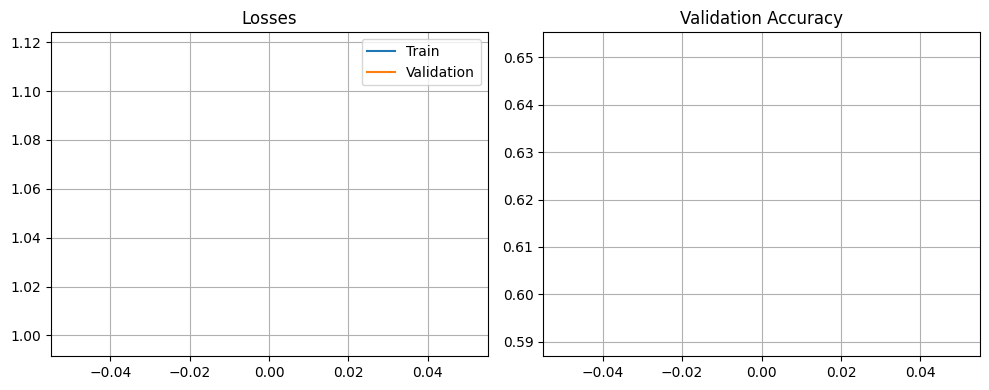

  1%|          | 1/100 [00:11<19:04, 11.56s/it]

Epoch 1: Train Loss = 0.9469, Val Loss = 0.9236, Val Acc = 0.6553


  2%|▏         | 2/100 [00:22<18:22, 11.25s/it]

Best model saved!
Epoch 2: Train Loss = 0.8887, Val Loss = 0.8884, Val Acc = 0.6747


  3%|▎         | 3/100 [00:33<18:04, 11.18s/it]

...

Best model saved!


  9%|▉         | 9/100 [01:38<16:23, 10.81s/it]

Epoch 8: Train Loss = 0.7915, Val Loss = 0.8393, Val Acc = 0.6895
Epoch 9: Train Loss = 0.7858, Val Loss = 0.8190, Val Acc = 0.7030


 10%|█         | 10/100 [01:49<16:19, 10.88s/it]

Best model saved!
Epoch 10: Train Loss = 0.7774, Val Loss = 0.8140, Val Acc = 0.6953


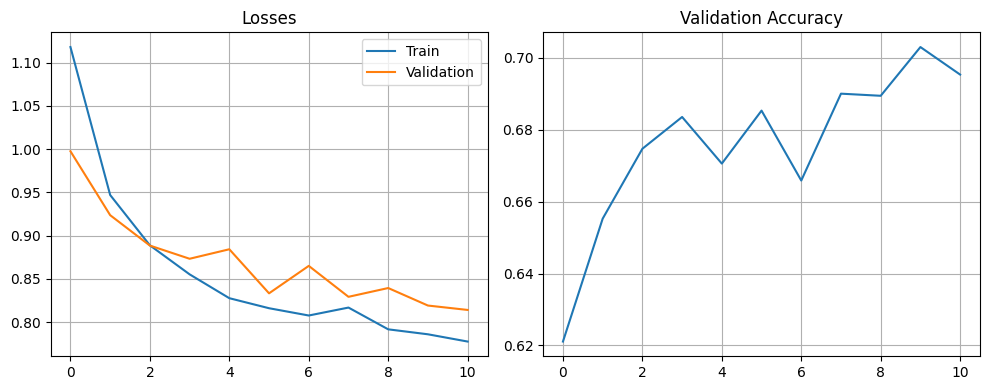

 12%|█▏        | 12/100 [02:10<15:44, 10.73s/it]

Epoch 11: Train Loss = 0.7594, Val Loss = 0.8288, Val Acc = 0.6900
Epoch 12: Train Loss = 0.7538, Val Loss = 0.8455, Val Acc = 0.7118


 13%|█▎        | 13/100 [02:21<15:41, 10.82s/it]

Best model saved!


 14%|█▍        | 14/100 [02:32<15:23, 10.74s/it]

...

Epoch 17: Train Loss = 0.7281, Val Loss = 0.8011, Val Acc = 0.7030


 19%|█▉        | 19/100 [03:25<14:17, 10.58s/it]

Epoch 18: Train Loss = 0.7415, Val Loss = 0.8053, Val Acc = 0.7060


 20%|██        | 20/100 [03:35<14:06, 10.58s/it]

Epoch 19: Train Loss = 0.7370, Val Loss = 0.8242, Val Acc = 0.7054
Epoch 20: Train Loss = 0.7266, Val Loss = 0.8198, Val Acc = 0.6818


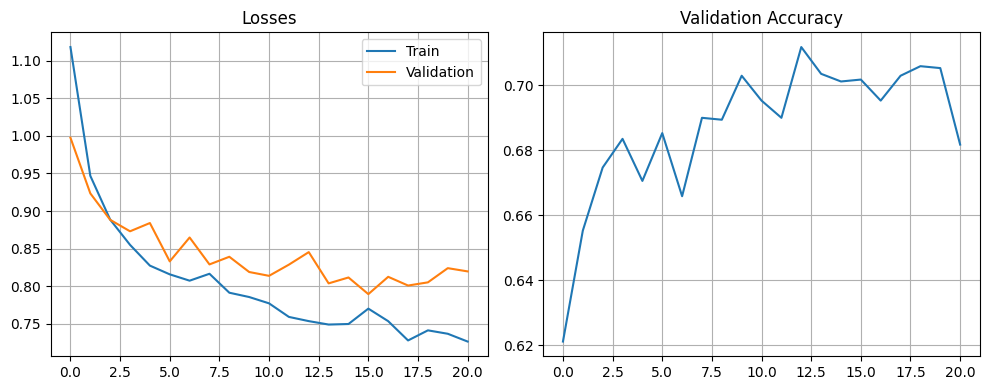

 21%|██        | 21/100 [03:46<13:57, 10.61s/it]

Epoch 21: Train Loss = 0.7422, Val Loss = 0.7936, Val Acc = 0.7213


 22%|██▏       | 22/100 [03:57<13:58, 10.75s/it]

Best model saved!


 23%|██▎       | 23/100 [04:08<13:42, 10.69s/it]

...

Epoch 27: Train Loss = 0.7127, Val Loss = 0.8004, Val Acc = 0.6918


 29%|██▉       | 29/100 [05:11<12:31, 10.58s/it]

Epoch 28: Train Loss = 0.7230, Val Loss = 0.8138, Val Acc = 0.6942


 30%|███       | 30/100 [05:22<12:20, 10.58s/it]

Epoch 29: Train Loss = 0.7281, Val Loss = 0.7929, Val Acc = 0.6977
Epoch 30: Train Loss = 0.7139, Val Loss = 0.8000, Val Acc = 0.7130


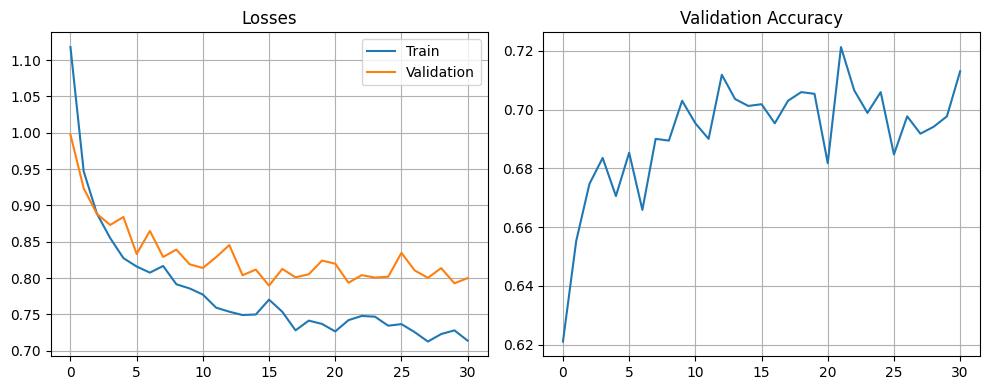

 32%|███▏      | 32/100 [05:43<12:00, 10.60s/it]

Epoch 31: Train Loss = 0.7128, Val Loss = 0.7885, Val Acc = 0.7071


 33%|███▎      | 33/100 [05:53<11:49, 10.59s/it]

Epoch 32: Train Loss = 0.7277, Val Loss = 0.7707, Val Acc = 0.6971


 34%|███▍      | 34/100 [06:04<11:38, 10.58s/it]

...

Epoch 37: Train Loss = 0.7443, Val Loss = 0.8019, Val Acc = 0.7101


 39%|███▉      | 39/100 [06:57<10:44, 10.57s/it]

Epoch 38: Train Loss = 0.6997, Val Loss = 0.7876, Val Acc = 0.7030


 40%|████      | 40/100 [07:07<10:33, 10.56s/it]

Epoch 39: Train Loss = 0.7152, Val Loss = 0.7961, Val Acc = 0.6989
Epoch 40: Train Loss = 0.7143, Val Loss = 0.7945, Val Acc = 0.7024


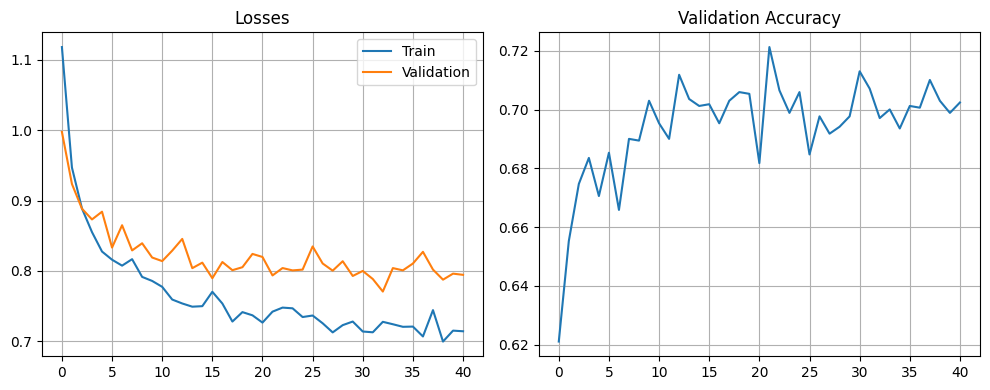

 42%|████▏     | 42/100 [07:29<10:13, 10.58s/it]

Epoch 41: Train Loss = 0.7064, Val Loss = 0.8103, Val Acc = 0.7036


 43%|████▎     | 43/100 [07:39<10:02, 10.57s/it]

Epoch 42: Train Loss = 0.7018, Val Loss = 0.7736, Val Acc = 0.7142


 44%|████▍     | 44/100 [07:50<09:53, 10.60s/it]

...

Epoch 47: Train Loss = 0.7081, Val Loss = 0.7873, Val Acc = 0.6995


 49%|████▉     | 49/100 [08:42<08:58, 10.56s/it]

Epoch 48: Train Loss = 0.7068, Val Loss = 0.7835, Val Acc = 0.7142


 50%|█████     | 50/100 [08:53<08:47, 10.56s/it]

Epoch 49: Train Loss = 0.7059, Val Loss = 0.7774, Val Acc = 0.7077
Epoch 50: Train Loss = 0.7019, Val Loss = 0.7926, Val Acc = 0.6977


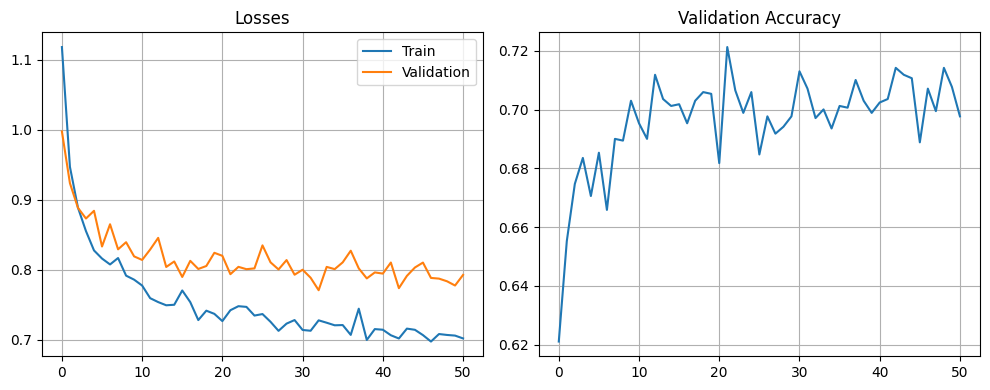

 52%|█████▏    | 52/100 [09:14<08:27, 10.58s/it]

Epoch 51: Train Loss = 0.7044, Val Loss = 0.7698, Val Acc = 0.7113


 53%|█████▎    | 53/100 [09:25<08:16, 10.57s/it]

Epoch 52: Train Loss = 0.7040, Val Loss = 0.7903, Val Acc = 0.7113


 54%|█████▍    | 54/100 [09:35<08:05, 10.56s/it]

...

Epoch 57: Train Loss = 0.6918, Val Loss = 0.7570, Val Acc = 0.7207


 59%|█████▉    | 59/100 [10:28<07:12, 10.55s/it]

Epoch 58: Train Loss = 0.7081, Val Loss = 0.8201, Val Acc = 0.7095


 60%|██████    | 60/100 [10:39<07:02, 10.55s/it]

Epoch 59: Train Loss = 0.6945, Val Loss = 0.7617, Val Acc = 0.7101
Epoch 60: Train Loss = 0.7129, Val Loss = 0.7960, Val Acc = 0.7001


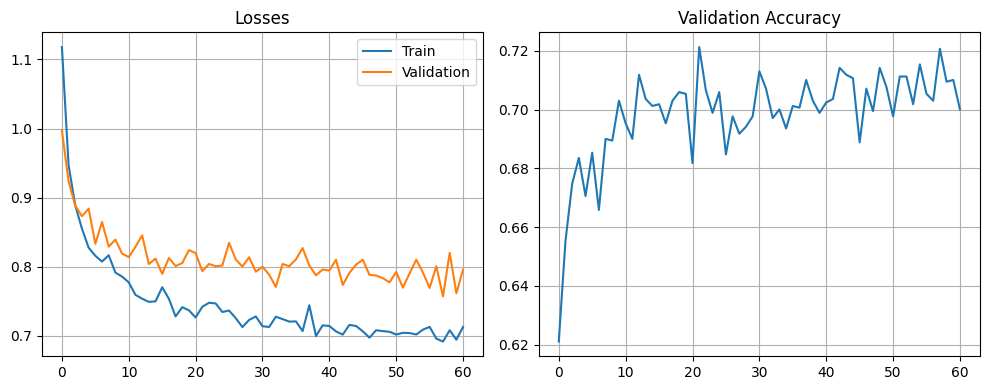

 62%|██████▏   | 62/100 [11:00<06:42, 10.58s/it]

Epoch 61: Train Loss = 0.6993, Val Loss = 0.7828, Val Acc = 0.7054


 63%|██████▎   | 63/100 [11:10<06:31, 10.58s/it]

Epoch 62: Train Loss = 0.7104, Val Loss = 0.7969, Val Acc = 0.7089


 64%|██████▍   | 64/100 [11:21<06:20, 10.57s/it]

...

Epoch 67: Train Loss = 0.7158, Val Loss = 0.7843, Val Acc = 0.7089


 69%|██████▉   | 69/100 [12:14<05:27, 10.55s/it]

Epoch 68: Train Loss = 0.6966, Val Loss = 0.7849, Val Acc = 0.6977


 70%|███████   | 70/100 [12:24<05:16, 10.56s/it]

Epoch 69: Train Loss = 0.7165, Val Loss = 0.7759, Val Acc = 0.7083
Epoch 70: Train Loss = 0.6916, Val Loss = 0.8033, Val Acc = 0.7018


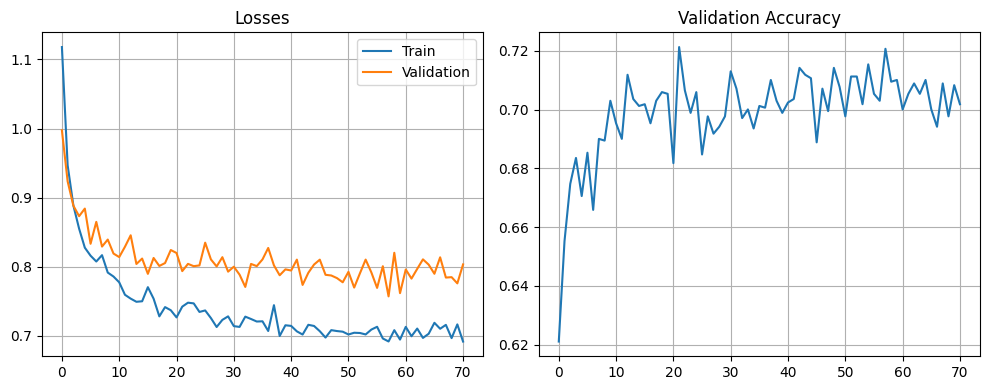

 72%|███████▏  | 72/100 [12:46<04:56, 10.58s/it]

Epoch 71: Train Loss = 0.7027, Val Loss = 0.7731, Val Acc = 0.7148


 73%|███████▎  | 73/100 [12:56<04:45, 10.57s/it]

Epoch 72: Train Loss = 0.7002, Val Loss = 0.8137, Val Acc = 0.6995


 74%|███████▍  | 74/100 [13:07<04:34, 10.57s/it]

Epoch 73: Train Loss = 0.6906, Val Loss = 0.7898, Val Acc = 0.7071


 74%|███████▍  | 74/100 [13:08<04:37, 10.66s/it]


KeyboardInterrupt: 

In [23]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.1)
criterion = nn.CrossEntropyLoss()

model = train(
    train_loader=resnet_train_loader,
    val_loader=resnet_val_loader,
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=100,
    model_name='best_resnet'
)

In [25]:
model.load_state_dict(torch.load('./models/best_resnet.pth'))

<All keys matched successfully>

In [26]:
df_ss = pd.read_csv("./Data/sample_submission_file.csv")
df_ss.head()

,Category,Id
0,cbsd,test-img-0.jpg
1,cmd,test-img-1.jpg
2,cbb,test-img-2.jpg
3,cmd,test-img-3.jpg
4,cbsd,test-img-4.jpg


In [27]:
paths = test_dataset.imgs
classes = train_dataset.classes

img_pred = dict()

model = model.cpu()
model.eval()

with torch.no_grad():
    for i in trange(len(test_dataset)):
        X = test_dataset[i][0]
        X = X.unsqueeze(0)
        
        name = os.path.basename(paths[i][0])
        
        pred = model(X)
        pred_class = pred.argmax(dim=1).item()
        
        img_pred[name] = classes[pred_class]

  0%|          | 0/3774 [00:00<?, ?it/s]

100%|██████████| 3774/3774 [05:29<00:00, 11.46it/s]


In [28]:
df_ss['Category'] = df_ss['Id'].map(img_pred)
df_ss.to_csv('./subms/subm_resnet.csv', index=False)